In [ ]:
from pathlib import Path

import bofire.strategies.api as strategies
import bofire.surrogates.api as surrogates
from bofire.benchmarks.api import Hartmann
from bofire.data_models.strategies.api import SoboStrategy
from bofire.data_models.surrogates.api import (
    BotorchSurrogates,
    SingleTaskGPSurrogate,
    TabPFNSurrogate,
)
from bofire.runners.api import run


# Absolute path — keeps loading independent of the notebook's CWD and skips
# TabPFN's HF-download / license-acceptance path entirely.
CHECKPOINT = Path(
    "/Users/j30607/sandbox/bofire-worktrees/feature-pfn/tabpfn-v3-regressor-v3_20260417_mediumdata.ckpt"
)
assert CHECKPOINT.exists(), f"Checkpoint not found at {CHECKPOINT}"

benchmark = Hartmann()
experiments = benchmark.f(benchmark.domain.inputs.sample(100), return_complete=True)
experiments_test = benchmark.f(benchmark.domain.inputs.sample(10), return_complete=True)

surrogate_data = TabPFNSurrogate(
    inputs=benchmark.domain.inputs,
    outputs=benchmark.domain.outputs,
    checkpoint_path=str(CHECKPOINT),
    tabpfn_version="v3",
)

surrogate = surrogates.map(surrogate_data)
surrogate.fit(experiments)

cv_train, cv_test, _ = surrogate.cross_validate(experiments, folds=10)
cv_test.get_metrics()

,MAE,MSD,R2,MAPE,PEARSON,SPEARMAN,FISHER
0,0.136884,0.049136,0.67601,25.967713,0.826183,0.862382,5.295177e-19


In [ ]:
default_results = run(
    benchmark=Hartmann(),
    strategy_factory=lambda domain: strategies.map(SoboStrategy(domain=domain)),
    metric=lambda domain, experiments: experiments.y.min(),
    initial_sampler=lambda domain: domain.inputs.sample(10),
    n_iterations=50,
    n_candidates_per_proposal=1,
    n_runs=1,
    n_procs=1,
)

Run 0: 100%|██████████| 50/50 [00:19<00:00,  2.56it/s, Current Best:=-3.316]


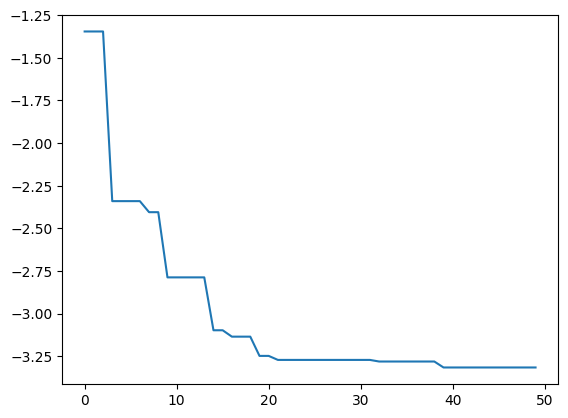

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots()

ax.plot(default_results[0][1])

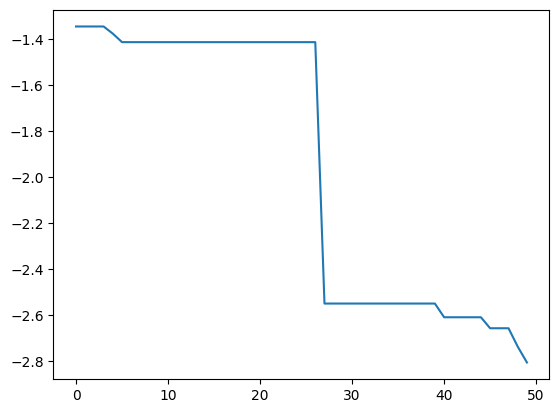

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots()

ax.plot(default_results[0][1])

In [ ]:
benchmark = Hartmann()

surrogate_data = TabPFNSurrogate(
    inputs=benchmark.domain.inputs,
    outputs=benchmark.domain.outputs,
    checkpoint_path=str(CHECKPOINT),
    tabpfn_version="v3",
)

surrogate_specs = BotorchSurrogates(surrogates=[surrogate_data])
start_experiments = default_results[0][0].loc[:9].copy()

default_results = run(
    benchmark=Hartmann(),
    strategy_factory=lambda domain: strategies.map(
        SoboStrategy(domain=domain, surrogate_specs=surrogate_specs)
    ),
    metric=lambda domain, experiments: experiments.y.min(),
    initial_sampler=lambda domain: start_experiments[domain.inputs.get_keys()].copy(),
    n_iterations=50,
    n_candidates_per_proposal=1,
    n_runs=1,
    n_procs=1,
)

  0%|          | 0/50 [00:00<?, ?it/s]

Run 0:  10%|█         | 5/50 [02:39<26:59, 35.99s/it, Current Best:=-1.377]/Users/j30607/sandbox/bofire-worktrees/feature-pfn/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
Run 0:  14%|█▍        | 7/50 [04:50<35:42, 49.83s/it, Current Best:=-1.414]/Users/j30607/sandbox/bofire-worktrees/feature-pfn/.venv/lib/python3.13/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=op

In [ ]:
default_results[0][1]

0    -1.346039
1    -1.346039
2    -1.346039
3    -2.340729
4    -2.340729
5    -2.340729
6    -2.340729
7    -2.405481
8    -2.405481
9    -2.787722
10   -2.787722
11   -2.787722
12   -2.787722
13   -2.787722
14   -3.097816
15   -3.097816
16   -3.135244
17   -3.135244
18   -3.135244
19   -3.248074
20   -3.248074
21   -3.271630
22   -3.271630
23   -3.271630
24   -3.271630
25   -3.271630
26   -3.271630
27   -3.271630
28   -3.271630
29   -3.271630
30   -3.271630
31   -3.271630
32   -3.281020
33   -3.281020
34   -3.281020
35   -3.281020
36   -3.281020
37   -3.281020
38   -3.281020
39   -3.315976
40   -3.315976
41   -3.315976
42   -3.315976
43   -3.315976
44   -3.315976
45   -3.315976
46   -3.315976
47   -3.315976
48   -3.315976
49   -3.315976
dtype: float64

In [ ]:
surrogate_data = SingleTaskGPSurrogate(
    inputs=benchmark.domain.inputs,
    outputs=benchmark.domain.outputs,
    # checkpoint_path=str(CHECKPOINT),
    # tabpfn_version="v2",
)

surrogate = surrogates.map(surrogate_data)
surrogate.fit(experiments)

cv_train, cv_test, _ = surrogate.cross_validate(experiments, folds=10)
cv_test.get_metrics()

,MAE,MSD,R2,MAPE,PEARSON,SPEARMAN,FISHER
0,0.173599,0.066005,0.511524,9.355098,0.729217,0.771737,6.517577e-11


In [ ]:
cv_test.get_metrics()

,MAE,MSD,R2,MAPE,PEARSON,SPEARMAN,FISHER
0,0.037648,0.006472,0.953526,0.380994,0.976489,0.984899,9.794102e-121


In [ ]:
surrogate.predict(experiments_test)

,y_pred,y_sd
0,-1.139064,2.410651
1,-0.422482,0.856231
2,-0.186873,0.497236
3,-0.078582,0.249490
4,-0.146110,0.383618
5,-0.811009,1.076747
6,-0.224200,0.589494
7,-0.596038,0.936974
8,-0.089597,0.443484
9,-0.245835,0.796743


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from tabpfn import TabPFNRegressor


input_keys = benchmark.domain.inputs.get_keys()
X = experiments[input_keys].to_numpy()
y = experiments["y"].to_numpy()

# n_estimators=1 disables ensembling; model_path skips download/license path.
reg = TabPFNRegressor(model_path=str(CHECKPOINT), n_estimators=1)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mae = -cross_val_score(reg, X, y, cv=kf, scoring="neg_mean_absolute_error")
r2 = cross_val_score(reg, X, y, cv=kf, scoring="r2")
print(f"MAE: mean={mae.mean():.4f}, std={mae.std():.4f}")
print(f"R2:  mean={r2.mean():.4f}, std={r2.std():.4f}")

MAE: mean=0.0446, std=0.0062
R2:  mean=0.9177, std=0.0587


In [ ]:
strategy_data = SoboStrategy(
    domain=benchmark.domain,
    surrogate_specs=BotorchSurrogates(surrogates=[surrogate_data]),
)
strategy = strategies.map(strategy_data)
strategy.tell(experiments)
candidates = strategy.ask(1)

In [ ]:
candidates

,x_0,x_1,x_2,x_3,x_4,x_5,y_pred,y_sd,y_des
0,0.447689,1.0,1.0,0.680914,0.0,0.0,-3.959882,4.525359,3.959882


In [ ]:
import pandas as pd

from bofire.data_models.constraints.api import (
    LinearInequalityConstraint,
    NChooseKConstraint,
)
from bofire.data_models.domain.api import Domain
from bofire.data_models.features.api import (
    CategoricalTaskInput,
    ContinuousInput,
    ContinuousOutput,
)
from bofire.data_models.objectives.api import MaximizeObjective
from bofire.strategies.api import MultiFidelityVarianceBasedStrategy


carbons = ["glucose", "glycerol", "lactose", "sucrose", "xylose"]
inputs = [ContinuousInput(key=k, bounds=(0.0, 50.0)) for k in carbons]
inputs.append(
    CategoricalTaskInput(key="fidelity", categories=["lo", "hi"], fidelities=[1, 0])
)
y = ContinuousOutput(key="titer", objective=MaximizeObjective(w=1.0))

constraints = [
    LinearInequalityConstraint.from_smaller_equal(
        features=carbons, coefficients=[1.0] * 5, rhs=100.0
    ),
    LinearInequalityConstraint.from_smaller_equal(
        features=carbons, coefficients=[0.020, 0.015, 0.030, 0.025, 0.040], rhs=1.20
    ),
    NChooseKConstraint(
        features=carbons, min_count=1, max_count=2, none_also_valid=False
    ),
]
domain = Domain.from_lists(inputs=inputs, outputs=[y], constraints=constraints)

seed = pd.DataFrame(
    [
        {
            "glucose": 20,
            "glycerol": 0,
            "lactose": 0,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "lo",
            "titer": 80,
            "valid_titer": 1,
        },
        {
            "glucose": 0,
            "glycerol": 15,
            "lactose": 0,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "lo",
            "titer": 90,
            "valid_titer": 1,
        },
        {
            "glucose": 10,
            "glycerol": 5,
            "lactose": 0,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "lo",
            "titer": 95,
            "valid_titer": 1,
        },
        {
            "glucose": 0,
            "glycerol": 0,
            "lactose": 10,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "lo",
            "titer": 70,
            "valid_titer": 1,
        },
        {
            "glucose": 15,
            "glycerol": 0,
            "lactose": 0,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "hi",
            "titer": 100,
            "valid_titer": 1,
        },
        {
            "glucose": 0,
            "glycerol": 10,
            "lactose": 0,
            "sucrose": 0,
            "xylose": 0,
            "fidelity": "hi",
            "titer": 105,
            "valid_titer": 1,
        },
    ]
)

strategy = MultiFidelityVarianceBasedStrategy.make(domain=domain, seed=42)
strategy.tell(seed)
candidates = strategy.ask(
    candidate_count=1
)  # ConstraintNotFulfilledError observed in higher-dim campaign

In [ ]:
candidates

,glucose,glycerol,lactose,sucrose,xylose,fidelity,titer_pred,titer_sd,titer_des
0,11.125023,9.379493,0.0,0.0,0.0,lo,97.098986,4.748484,97.098986
